#**Store Sales Forecasting Dataset**

#**Import Library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

##**Memuat Dataset**

In [ ]:
file = '/content/drive/MyDrive/CP1 AVD/stores_sales_forecasting.csv'
df = pd.read_csv(file, encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [ ]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
2120,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332


#**Bussiness Understanding**

##**Bussiness Objective**

Dataset yang digunakan pada analisis ini berisi data penjualan dari beberapa toko yang mencakup informasi seperti tanggal transaksi, produk, promo dan jumlah barang yang terjual. Melalui data ini, analisis dilakukan untuk mengetahui pola penjualan serta faktor faktor yang mempengaruhi naik turunnya sales sehingga hasilnya bisa membantu perusahaan dalam menyusun strategi promosi, mengatur persediaan barang dan merencanakan target penjualan di periode berikutnya.

##**Assess Situation**

Walaupun perusahaan sudah punya data penjualan dalam jumlah besar. Informasi tersebut belum dimanfaatkan dengan baik hingga masih kesulitan untuk mengetahui waktu penjualan paling tinggi, dampak promo terhadap sales, cara mengatur stock dan memperkirakan penjualan selanjutnya, oleh karena itu diperlukan analisis data untuk mendapatkan insight yang bisa membantu pengambilan keputusan.

##**Analytic Goals**

Tujuan analisis data yang ingin dicapai dari proyek ini adalah:

1. Mengetahui perkembangan penjualan dari waktu ke waktu.
2. Mengetahui pengaruh promo terhadap jumlah penjualan.
3. Menyiapkan dasar informasi untuk prediksi penjualan di masa depan.

##**Project Plan**

Untuk mencapai tujuan tersebut. Langkah langkah yang akan dilakukan yaitu memuat dataset ke dalam Google Colab, memahami isi dan struktur data, lalu melakukan pembersihan jika terdapat data yang kosong/tidak sesuai, lalu melakukan eksplorasi untuk menemukan pola dan yang terakhir menarik insight dari hasil analisis yang telah dilakukan.

#**Data Understanding**

##**Memuat Dataset**

In [ ]:
file = pd.read_csv('/content/drive/MyDrive/CP1 AVD/stores_sales_forecasting.csv', encoding='latin1')
df = pd.DataFrame(file)
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


##**Struktur Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

###**Penjelasan**
Dari hasil tersebut bisa dilihat bahwa dataset memiliki beberapa tipe data seperti object, int64 dan float64. Artinya data terdiri dari variabel kategori dan numerik, adapun juga beberapa kolom yang memiliki missing value, sehingga perlu dilakukan yang namanya pembersihan data sebelum analisis lebih lanjut. Secara umum struktur data sudah cukup rapi akan tetapi tetap perlu dicek terus agar tidak ada kesalahan tipe data atau nilai kosong yang bisa mempengaruhi hasil analisis.

In [ ]:
df.shape

(2121, 21)

###**Penjelasan**
Dataset terdiri dari 2121 baris dan 21 kolom.

##**Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,2121.000000,2121,2121,2121,2121,2121,2121,2121,2121,2121,...,2121.000000,2121,2121,2121,2121,2121,2121.000000,2121.000000,2121.000000,2121.000000
unique,NaN,1764,889,960,4,707,707,3,1,371,...,NaN,4,375,1,4,380,NaN,NaN,NaN,NaN
top,NaN,US-2015-138121,9/5/2016,12/6/2017,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,NaN,West,FUR-FU-10004270,Furniture,Furnishings,KI Adjustable-Height Table,NaN,NaN,NaN,NaN
freq,NaN,4,10,10,1248,15,15,1113,2121,192,...,NaN,707,16,2121,957,18,NaN,NaN,NaN,NaN
mean,5041.643564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55726.556341,NaN,NaN,NaN,NaN,NaN,349.834887,3.785007,0.173923,8.699327
std,2885.740258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32261.888225,NaN,NaN,NaN,NaN,NaN,503.179145,2.251620,0.181547,136.049246
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22801.000000,NaN,NaN,NaN,NaN,NaN,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60505.000000,NaN,NaN,NaN,NaN,NaN,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90032.000000,NaN,NaN,NaN,NaN,NaN,435.168000,5.000000,0.300000,33.726600


###**Penjelasan**
Dataset berisi 2.121 transaksi tanpa missing values. Rata rata sales sebesar 349,83 dengan median 182,22 menunjukkan distribusi miring ke kanan karena adanya transaksi bernilai sangat tinggi. Quantity rata rata 3 sd 4 unit per transaksi dan relatif stabil. Discount rata rata sekitar 17% dengaan nilai maksimum 70% menandakan praktik diskon cukup agresif.

##**Cek Tipe Data Pada Setiap Kolom**

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


###**Penjelasan**
Struktur data sudah sesuai untuk analisis, tetapi kolom tanggal Order Date dan Ship Date masih bertipe object seharusnya format datetime.


In [ ]:
print(df['Row ID'].unique())

[   1    2    4 ... 9981 9990 9991]


In [ ]:
print(df['Order ID'].unique())

['CA-2016-152156' 'US-2015-108966' 'CA-2014-115812' ... 'US-2015-151435'
 'CA-2014-110422' 'CA-2017-121258']


In [ ]:
print(df['Order Date'].unique())

['11/8/2016' '10/11/2015' '6/9/2014' '7/16/2017' '9/25/2015' '9/17/2015'
 '12/8/2016' '12/27/2015' '4/18/2015' '6/17/2016' '11/24/2015' '4/30/2015'
 '4/26/2015' '12/9/2017' '11/26/2014' '5/28/2017' '1/31/2015' '11/9/2017'
 '11/13/2015' '12/25/2017' '3/2/2015' '6/12/2016' '12/26/2014' '9/20/2014'
 '11/6/2016' '10/13/2016' '9/5/2016' '10/22/2014' '12/5/2016' '3/1/2014'
 '9/8/2014' '8/5/2014' '11/21/2015' '10/12/2015' '8/3/2014' '6/3/2017'
 '1/2/2015' '12/24/2015' '8/9/2015' '2/28/2015' '4/7/2017' '6/4/2016'
 '6/1/2014' '12/10/2016' '11/28/2015' '7/30/2015' '11/2/2015' '11/20/2016'
 '10/28/2016' '11/19/2017' '5/4/2015' '9/12/2016' '9/27/2014' '11/4/2014'
 '11/3/2017' '8/30/2016' '7/12/2014' '4/8/2016' '9/25/2017' '10/21/2016'
 '8/27/2017' '11/27/2015' '12/3/2015' '9/8/2016' '12/8/2017' '4/14/2016'
 '10/19/2017' '8/21/2017' '11/23/2017' '1/20/2017' '3/20/2017'
 '10/20/2017' '2/12/2014' '9/26/2016' '4/22/2016' '1/17/2015' '3/31/2017'
 '11/9/2014' '10/27/2016' '6/10/2017' '3/18/2016' '7/25/2

In [ ]:
print(df['Ship Date'].unique())

['11/11/2016' '10/18/2015' '6/14/2014' '7/18/2017' '9/30/2015' '9/21/2015'
 '12/10/2016' '12/31/2015' '4/22/2015' '6/18/2016' '11/30/2015' '5/5/2015'
 '5/2/2015' '12/11/2017' '12/1/2014' '5/30/2017' '2/5/2015' '11/11/2017'
 '11/17/2015' '12/30/2017' '3/6/2015' '6/15/2016' '12/28/2014' '9/25/2014'
 '11/10/2016' '10/19/2016' '9/7/2016' '10/28/2014' '12/9/2016' '3/6/2014'
 '9/12/2014' '8/9/2014' '11/23/2015' '10/14/2015' '8/5/2014' '6/7/2017'
 '1/9/2015' '12/27/2015' '8/16/2015' '3/4/2015' '4/12/2017' '6/9/2016'
 '6/6/2014' '12/15/2016' '12/4/2015' '7/31/2015' '11/6/2015' '11/24/2016'
 '11/3/2016' '11/23/2017' '5/9/2015' '9/14/2016' '10/3/2014' '11/9/2014'
 '11/5/2017' '9/1/2016' '7/17/2014' '4/13/2016' '10/1/2017' '10/21/2016'
 '9/1/2017' '12/2/2015' '12/7/2015' '9/10/2016' '12/12/2017' '11/7/2017'
 '4/18/2016' '10/23/2017' '8/23/2017' '11/26/2017' '1/23/2017' '3/25/2017'
 '10/24/2017' '2/18/2014' '10/1/2016' '4/29/2016' '1/24/2015' '4/4/2017'
 '11/11/2014' '11/2/2016' '6/13/2017' '3/21/

In [ ]:
print(df['Ship Mode'].unique())

['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [ ]:
print(df['Customer ID'].unique())

['CG-12520' 'SO-20335' 'BH-11710' 'SF-20065' 'EB-13870' 'TB-21520'
 'GH-14485' 'SN-20710' 'DP-13000' 'TB-21055' 'KM-16720' 'PS-18970'
 'JE-15745' 'KB-16600' 'PO-18865' 'KB-16315' 'PN-18775' 'LC-16870'
 'CV-12805' 'DK-13090' 'SC-20725' 'AD-10180' 'PF-19165' 'LS-16975'
 'LC-16885' 'JD-15895' 'MG-17680' 'JE-16165' 'DB-13060' 'BM-11140'
 'CS-12130' 'MP-17470' 'BS-11755' 'HK-14890' 'VW-21775' 'JB-15925'
 'DS-13180' 'VD-21670' 'CS-12400' 'KL-16645' 'DW-13480' 'LH-17155'
 'DR-12880' 'HA-14920' 'JO-15280' 'NZ-18565' 'KL-16555' 'JH-15910'
 'AS-10225' 'BP-11185' 'TS-21205' 'NM-18445' 'DJ-13510' 'PO-18850'
 'AC-10420' 'JL-15505' 'KW-16435' 'MK-17905' 'AR-10405' 'DO-13435'
 'DK-13225' 'AG-10675' 'KH-16510' 'KC-16675' 'PB-19150' 'MP-17965'
 'NF-18385' 'JM-15265' 'PK-19075' 'TB-21595' 'EB-13705' 'SC-20095'
 'TN-21040' 'JS-15940' 'JP-15520' 'JE-15475' 'MT-18070' 'RO-19780'
 'MY-17380' 'LS-17245' 'MC-17605' 'PH-18790' 'KB-16240' 'JC-15340'
 'DK-12985' 'PG-18895' 'BD-11320' 'RC-19960' 'OT-18730' 'LP-17

In [ ]:
print(df['Customer Name'].unique())

['Claire Gute' "Sean O'Donnell" 'Brosina Hoffman' 'Sandra Flanagan'
 'Emily Burns' 'Tracy Blumstein' 'Gene Hale' 'Steve Nguyen'
 'Darren Powers' 'Ted Butterfield' 'Kunst Miller' 'Paul Stevenson'
 'Joel Eaton' 'Ken Brennan' "Patrick O'Donnell" 'Karl Braun'
 'Parhena Norris' 'Lena Cacioppo' 'Cynthia Voltz' 'Dave Kipp'
 'Steven Cartwright' 'Alan Dominguez' 'Philip Fox' 'Lindsay Shagiari'
 'Lena Creighton' 'Jonathan Doherty' 'Maureen Gastineau' 'Justin Ellison'
 'Dave Brooks' 'Becky Martin' 'Chad Sievert' 'Mark Packer' 'Bruce Stewart'
 'Heather Kirkland' 'Victoria Wilson' 'Joni Blumstein' 'David Smith'
 'Valerie Dominguez' 'Christopher Schild' 'Ken Lonsdale' 'Dianna Wilson'
 'Logan Haushalter' 'Dan Reichenbach' 'Helen Andreada' "Jas O'Carroll"
 'Nick Zandusky' 'Kelly Lampkin' 'Jonathan Howell' 'Alan Schoenberger'
 'Ben Peterman' 'Thomas Seio' 'Nathan Mautz' 'Don Jones' "Patrick O'Brill"
 'Alyssa Crouse' 'Jeremy Lonsdale' 'Katrina Willman' 'Michael Kennedy'
 'Allen Rosenblatt' 'Denny Ordway

In [ ]:
print(df['Segment'].unique())

['Consumer' 'Corporate' 'Home Office']


In [ ]:
print(df['Country'].unique())

['United States']


In [ ]:
print(df['City'].unique())

['Henderson' 'Fort Lauderdale' 'Los Angeles' 'Philadelphia' 'Orem'
 'Richardson' 'Houston' 'New Albany' 'Troy' 'Chicago' 'Memphis' 'Columbia'
 'Minneapolis' 'New York City' 'Aurora' 'Seattle' 'Wilmington'
 'Bloomington' 'Roseville' 'Newark' 'Franklin' 'San Antonio' 'Denver'
 'Medina' 'Dublin' 'Detroit' 'Tampa' 'Lakeville' 'San Francisco'
 'Columbus' 'Colorado Springs' 'Belleville' 'Arvada' 'Hackensack'
 'Murfreesboro' 'Manchester' 'Pembroke Pines' 'Lawrence' 'Jackson'
 'Canton' 'Akron' 'Concord' 'Decatur' 'Phoenix' 'Park Ridge' 'Amarillo'
 'Costa Mesa' 'Parker' 'Gladstone' 'Lakeland' 'Fort Worth' 'Jacksonville'
 'Richmond' 'San Diego' 'Dearborn' 'Warner Robins' 'Vallejo' 'Vancouver'
 'Arlington' 'Cleveland' 'Tyler' 'Waynesboro' 'Long Beach' 'Dover'
 'Oceanside' 'Trenton' 'Saint Petersburg' 'Des Moines' 'Lancaster'
 'Lake Elsinore' 'Omaha' 'Edmonds' 'Santa Ana' 'Florence' 'Louisville'
 'Lorain' 'Springfield' 'Rochester' 'Norwich' 'Milwaukee' 'Torrance'
 'Mesa' 'Round Rock' 'Auburn' 'Oly

In [ ]:
print(df['State'].unique())

['Kentucky' 'Florida' 'California' 'Pennsylvania' 'Utah' 'Texas' 'Indiana'
 'New York' 'Illinois' 'Tennessee' 'South Carolina' 'Minnesota' 'Colorado'
 'Washington' 'Delaware' 'Ohio' 'Wisconsin' 'Michigan' 'New Jersey'
 'Connecticut' 'Massachusetts' 'Mississippi' 'Arizona' 'Missouri'
 'Georgia' 'Virginia' 'Iowa' 'Nebraska' 'New Hampshire'
 'District of Columbia' 'North Carolina' 'Arkansas' 'Maryland' 'Alabama'
 'Nevada' 'Louisiana' 'Oregon' 'Oklahoma' 'Rhode Island' 'Maine'
 'South Dakota' 'New Mexico' 'Idaho' 'Vermont' 'Kansas' 'Wyoming'
 'Montana' 'West Virginia']


In [ ]:
print(df['Postal Code'].unique())

[42420 33311 90032 19140 84057 75080 77041 47150 12180 90004 60610 38109
 77070 29203 55407 10009 80013 10035 98103 19805 61701 95661 43055 53132
 98115 78207 80219 37064 44256 43017 48227 38401 33614 55044 94109 60623
 43229 80906  7109 10024 80004  7601 37130 19143 94122  6040  2038 33024
 77036 94110 98105  1841 39212 48187 47201 44312 94521 62521 85023 60068
 79109 90045 92627 80134 64118 48234 33801 90036 76106 32216 40475 92024
 10011 48126 31088 94591 98661 60505 76017 44105 60653 75701 22980 90805
 19901 48205 11572 92105 48183 33710 22204 50315 93534 23223 92530 68104
 98026 92704 41042 40214 44052 22153  3301 14609  6360 53209 90503 85204
 19120 78664 92054 19134 80027 13021 92037 98502 20016 65109 63376 61107
 33142 77095 10701 28110 90049 72401 44221 22801 20852 33065 33437 93727
 19013 46350 31907 91104 90008 60201 85705 90660 84604 30080 35630  6457
  8360 77506 85301 89031 18103 92677  2149 13601 79907 61604 75007 98031
 70506 94601 23434 53711 95123 98002 97756 74403 28

In [ ]:
print(df['Region'].unique())

['South' 'West' 'East' 'Central']


In [ ]:
print(df['Product ID'].unique())

['FUR-BO-10001798' 'FUR-CH-10000454' 'FUR-TA-10000577' 'FUR-FU-10001487'
 'FUR-TA-10001539' 'FUR-CH-10002774' 'FUR-BO-10004834' 'FUR-FU-10004848'
 'FUR-FU-10003664' 'FUR-BO-10002545' 'FUR-CH-10004218' 'FUR-FU-10001706'
 'FUR-CH-10003061' 'FUR-CH-10003968' 'FUR-FU-10000397' 'FUR-CH-10001146'
 'FUR-CH-10000513' 'FUR-FU-10003708' 'FUR-FU-10000260' 'FUR-FU-10003194'
 'FUR-CH-10000863' 'FUR-FU-10003799' 'FUR-FU-10000629' 'FUR-FU-10004006'
 'FUR-FU-10001934' 'FUR-TA-10001768' 'FUR-FU-10002157' 'FUR-CH-10004063'
 'FUR-TA-10004534' 'FUR-FU-10003773' 'FUR-FU-10000521' 'FUR-CH-10004287'
 'FUR-CH-10003817' 'FUR-CH-10004698' 'FUR-BO-10002613' 'FUR-TA-10004289'
 'FUR-FU-10002960' 'FUR-BO-10004695' 'FUR-FU-10000087' 'FUR-TA-10003748'
 'FUR-CH-10004860' 'FUR-CH-10004477' 'FUR-TA-10001705' 'FUR-TA-10003473'
 'FUR-FU-10004017' 'FUR-FU-10000576' 'FUR-FU-10004351' 'FUR-TA-10002607'
 'FUR-FU-10002505' 'FUR-CH-10002965' 'FUR-FU-10003274' 'FUR-TA-10002903'
 'FUR-BO-10004709' 'FUR-FU-10004091' 'FUR-CH-100018

In [ ]:
print(df['Category'].unique())

['Furniture']


In [ ]:
print(df['Sub-Category'].unique())

['Bookcases' 'Chairs' 'Tables' 'Furnishings']


In [ ]:
print(df['Product Name'].unique())

['Bush Somerset Collection Bookcase'
 'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back'
 'Bretford CR4500 Series Slim Rectangular Table'
 'Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood'
 'Chromcraft Rectangular Conference Tables'
 'Global Deluxe Stacking Chair, Gray'
 'Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish'
 'Howard Miller 13-3/4" Diameter Brushed Chrome Round Wall Clock'
 "Electrix Architect's Clamp-On Swing Arm Lamp, Black"
 'Atlantic Metals Mobile 3-Shelf Bookcases, Custom Colors'
 "Global Fabric Manager's Chair, Dark Gray" 'Longer-Life Soft White Bulbs'
 'Global Leather Task Chair, Black' 'Novimex Turbo Task Chair'
 'Luxo Economy Swing Arm Lamp'
 "Global Value Mid-Back Manager's Chair, Gray"
 "High-Back Leather Manager's Chair"
 'Tenex Traditional Chairmats for Medium Pile Carpet, Standard Lip, 36" x 48"'
 '6" Cubicle Wall Clock, Black'
 'Eldon Expressions Desk Accessory, Wood Pencil Holder, Oak'
 'Novimex Swivel Fabric Task Ch

In [ ]:
print(df['Sales'].unique())

[261.96   731.94   957.5775 ... 383.4656  13.4     25.248 ]


In [ ]:
print(df['Quantity'].unique())

[ 2  3  5  7  9  1  4  8  6 14 13 10 11 12]


In [ ]:
print(df['Discount'].unique())

[0.   0.45 0.2  0.3  0.5  0.6  0.32 0.1  0.15 0.4  0.7 ]


In [ ]:
print(df['Profit'].unique())

[  41.9136  219.582  -383.031  ...   10.2588    6.432     4.1028]


###**Kesimpulan**
Jadi kesimpulannya adalah Data yang terdapat incostent valuenya yaitu Customer Name, untuk data yang lain masih konsisten.

##**Cek Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Row ID,0.0
Order ID,0.0
Order Date,0.0
Ship Date,0.0
Ship Mode,0.0
Customer ID,0.0
Customer Name,0.0
Segment,0.0
Country,0.0
City,0.0


###**Penjelasan**
Kode di atas menghitung persentase nilai kosong untuk setiap kolom dalam DataFrame. Outputnya akan menampilkan setiap kolom beserta rasio nilai kosongnya dalam persentase, membantu kita mengidentifikasi kolom mana yang memiliki data yang hilang dan seberapa banyak. Jadi intinya adalah data tersebut tidak ada yang namanya Missing Values.

##**Cek Duplicated Values**

In [ ]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


###**Penjelasan**
Tidak ada data values yang terduplikat.

##**Cek Outliers**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Row ID,0.000000
Postal Code,0.000000
Sales,7.732202
Quantity,1.838755
Discount,0.000000
Profit,19.189062


###**Penjelasan**

Analisis outlier menunjukan bahwa Row ID, Postal Code dan Quantity tidak memiliki outlier, menandakan bahwa data pada kolom tersebut stabil. Sales memiliki sekitar 10% outlier yang menunjukan adanya transaksi bernilai sngat tinggi dan dapat memengaruhi rata rata penjualan.

#**EDA**

##**Comparison(Perbandingan)**

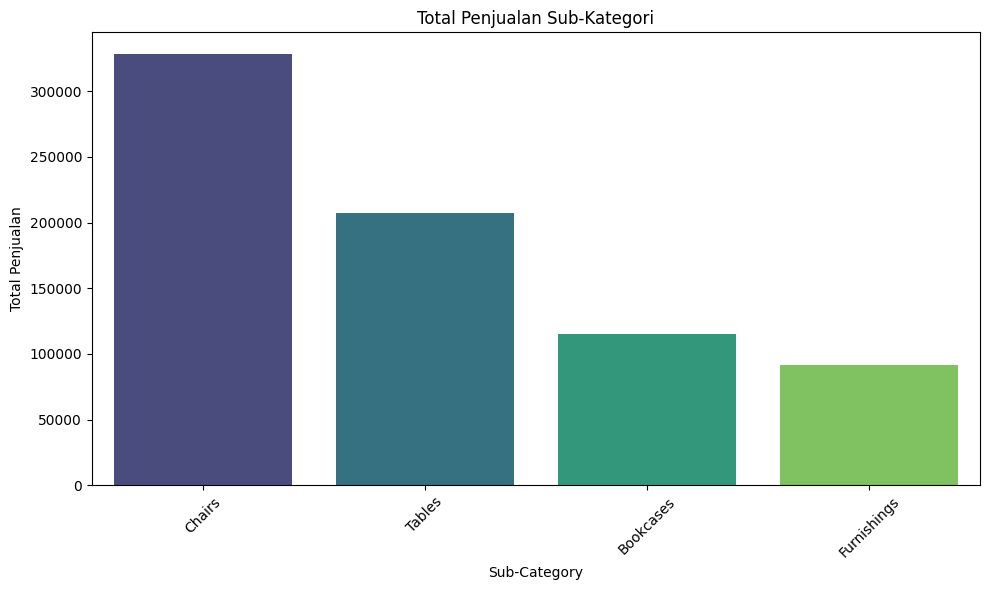

In [ ]:
variabel = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=variabel.index, y=variabel.values, palette='viridis', hue=variabel.index, legend=False)
plt.title('Total Penjualan Sub-Kategori')
plt.xlabel('Sub-Category')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###**Penjelasan**
Kursi memiliki total penjualan tertinggi sehingga dapat disimpulkan sebagai penyumbang pendapatan terbesar dalam sub-kategori furnitur. Meja berada di posisi kedua dengan kontribusi penjualan yang juga cukup kuat. Rak buku dan perlengkapan rumah mencatat penjualan yang jauh lebih rendah, dengan perlengkapan rumah menjadi yang terendah. Hal tersebut menunjukan bahwa strategi pemasaran/pengembangan produk sebaiknya difokuskan buat meningkatkan performa sub-kategori yang masih bisa dibilang lemah sekaligus mempertahankan kinerja baik pada kursi dan meja.

##**Composition(Komposisi)**

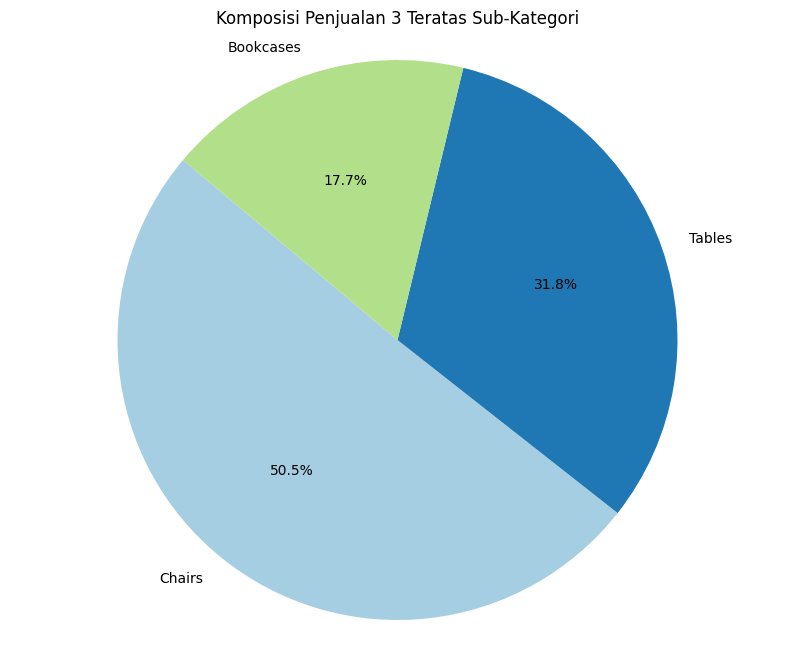

In [ ]:
variabel = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
variabel2 = variabel.head(3)

plt.figure(figsize=(10, 8))
variabel2.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Komposisi Penjualan 3 Teratas Sub-Kategori')
plt.ylabel('')
plt.axis('equal')
plt.show()

###**Penjelasan**
Komposisi penjualan menunjukkan bahwa kursi mendominasi dengan sekitar 50,5% dari total penjualan, diikuti oleh meja dengan sekitaar sebesar 31,8%, sementara itu rak buku hanya menyumbang sebanyak 17,7%, sehingga kursi menjadi kontributor utama pendapatan dan rak buku paling lemah.

##**Distribution(Distribusi)**

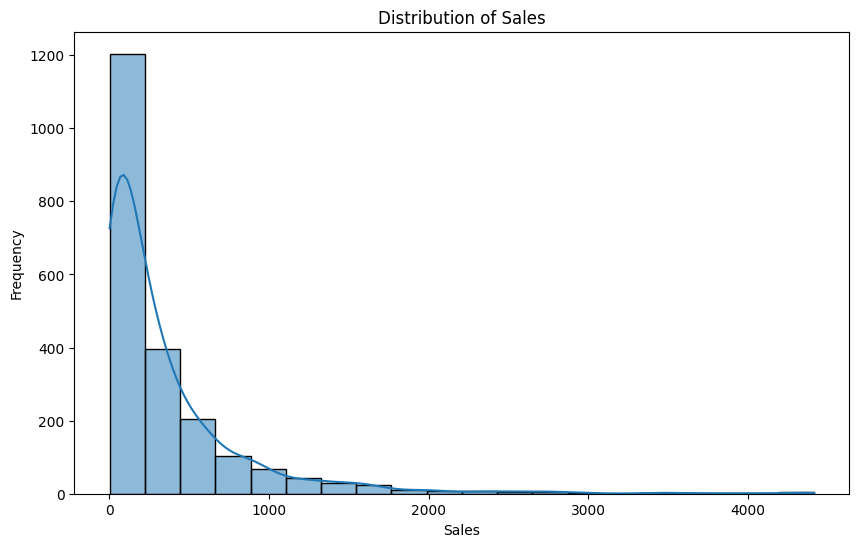

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

###**Penjelasan**
Distribusi penjualan menunjukkan pola right skewed atau mereng kanan yang berarti sebagian besar transaksi bernilai kecil. sementara hanya sedikit transaksi bernilai sangat besar (outlier) sehingga dapat disimpulkan bahwa pendapatan perusahaan banyak ditopang oleh sebagian kecil order dengan nilai tinggi.

##**Relationship/Hubungan**

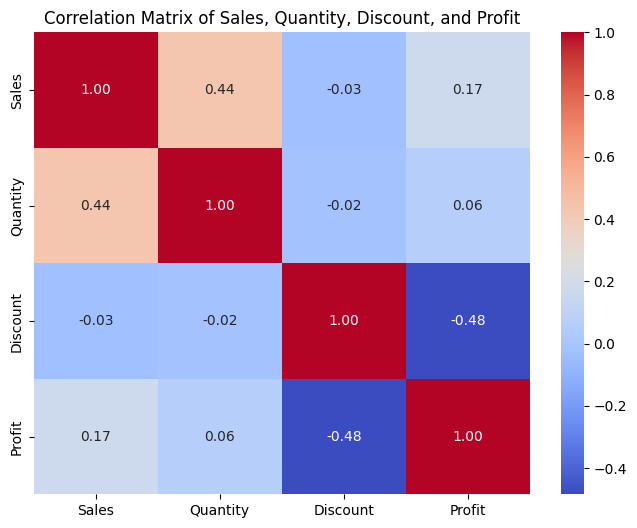

In [ ]:
correlation_data = df[['Sales', 'Quantity', 'Discount', 'Profit']]

plt.figure(figsize=(8, 6))
sns.heatmap(data=correlation_data.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Matrix of Sales, Quantity, Discount, and Profit')
plt.show()

###**Penjelasan**
Analisis korelasi menunjukkan bahwa sales dan quantity berkorelasi positif sedang (0,44), sedangkan discount berkorelasi negatif cukup kuat terhadap profit (-0,48), yang berarti semakin besar diskon maka profit cenderung turun. Sementara itu, hubungan sales–profit (0,17) dan quantity–profit (0,06) tergolong lemah sehingga peningkatan penjualan atau jumlah unit tidak selalu menaikkan profit.

# **Data Preparation**

## **Tipe Data**

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

Terlihat bahwa banyak tipe data yang salah seperti, Order Date dan Ship Date yang seharusnya tipe data (datetime) bukan object.

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

### **Penjelasan**

Ditahap ini saya melakukan Konversi tipe data seperti Kolom Order Date dan Ship Date menjadi datetime karena keduanya merupakan data temporal yang digunakan untuk analisis tren penjualan dan perhitungan selisih waktu pengiriman.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2121 non-null   int64         
 1   Order ID       2121 non-null   object        
 2   Order Date     2121 non-null   datetime64[ns]
 3   Ship Date      2121 non-null   datetime64[ns]
 4   Ship Mode      2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  Postal Code    2121 non-null   int64         
 12  Region         2121 non-null   object        
 13  Product ID     2121 non-null   object        
 14  Category       2121 non-null   object        
 15  Sub-Category   2121 n

## **Incosistent Values**

### **Customer Name**

In [ ]:
# Menghapus angka dan simbol dari nama pelanggan agar konsisten
df['Customer Name'] = df['Customer Name'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

### **Penjelasan**

Pada tahap ini, saya melakukan pembersihan karakter non-alfabet seperti angka dan simbol pada kolom Customer Name dengan tujuan menormalkan data identitas pelanggan, sehingga analisis frekuensi belanja per individu dapat menghasilkan data yang valid dan tidak terpecah akibat adanya karakter yang tidak relevan.

### **Product Name**

In [ ]:
# Menghapus tanda petik yang tidak konsisten di awal atau akhir string
df['Product Name'] = df['Product Name'].str.strip("'").str.strip('"')

### **Penjelasan**

Pada tahap ini, tanda petik yang tidak berpasangan pada kolom Product Name dibersihkan dengan tujuan menyeragamkan penulisan nama produk, sehingga sistem dapat mengidentifikasi barang secara konsisten dan menghindari duplikasi entitas akibat perbedaan karakter penulisan.

## **Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Row ID,0.0
Order ID,0.0
Order Date,0.0
Ship Date,0.0
Ship Mode,0.0
Customer ID,0.0
Customer Name,0.0
Segment,0.0
Country,0.0
City,0.0


### **Penjelasan**

Pada tahap ini, hasil pemeriksaan rasio data kosong menunjukkan nilai 0% pada seluruh 21 kolom, sehingga dataset bisa di bilang bersih dari missing values dan dapat langsung digunakan untuk proses lanjutan tanpa perlu menerapkan metode imputasi seperti pengisian nilai rata-rata atau median.

## **Duplicated Values**

In [ ]:
df = df.drop_duplicates()

### **Penjelasan**

Pada tahap ini, baris data yang bersifat duplikat dihapus menggunakan fungsi drop_duplicates() untuk menjaga integritas dataset, sehingga setiap transaksi hanya tercatat satu kali. Langkah ini sangat penting dalam analisis 21 kolom agar tidak terjadi penggandaan nilai pada metrik numerik seperti Sales dan Profit yang berpotensi menimbulkan hasil analisis keuangan yang tidak akurat.

## **Outliers**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Row ID,0.000000
Postal Code,0.000000
Sales,7.732202
Quantity,1.838755
Discount,0.000000
Profit,19.189062


### **Profit**

In [ ]:
# Menghitung batas IQR untuk kolom Profit
Q1_profit = df['Profit'].quantile(0.25)
Q3_profit = df['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

lower_limit = Q1_profit - 1.5 * IQR_profit
upper_limit = Q3_profit + 1.5 * IQR_profit

# Menerapkan Clipping (mengganti nilai di luar batas dengan nilai batas tersebut)
df['Profit'] = df['Profit'].clip(lower=lower_limit, upper=upper_limit)

# Ulangi hal yang sama untuk kolom Sales jika diperlukan

### **Penjelasan**

Pada tahap ini, penanganan pencilan pada kolom Profit dan Sales dilakukan dengan metode clipping untuk mengurangi pengaruh nilai ekstrem tanpa menghilangkan baris data, sehingga kestabilan statistik dataset tetap terjaga dan model prediksi tidak terpengaruh oleh fluktuasi transaksi yang tidak wajar.

### **Sales**

In [ ]:
# Menghitung batas IQR untuk kolom Sales
Q1_sales = df['Sales'].quantile(0.25)
Q3_sales = df['Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

lower_s = Q1_sales - 1.5 * IQR_sales
upper_s = Q3_sales + 1.5 * IQR_sales

# Menerapkan Clipping pada Sales
df['Sales'] = df['Sales'].clip(lower=lower_s, upper=upper_s)

Pada tahap ini, normalisasi pada kolom Sales dilakukan menggunakan metode clipping untuk menekan lonjakan transaksi yang bersifat anomali, sehingga model peramalan mampu menangkap pola penjualan yang lebih stabil dan menghasilkan prediksi pendapatan yang lebih realistis bagi perusahaan.

### **Quantity**

In [ ]:
# Menghitung batas IQR untuk kolom Quantity
Q1_qty = df['Quantity'].quantile(0.25)
Q3_qty = df['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty

lower_q = Q1_qty - 1.5 * IQR_qty
upper_q = Q3_qty + 1.5 * IQR_qty

# Menerapkan Clipping pada Quantity
df['Quantity'] = df['Quantity'].clip(lower=lower_q, upper=upper_q)

### **Penjelasan**

Pada tahap ini, penanganan pencilan pada kolom Quantity dilakukan dengan membatasi nilai pesanan yang terlalu ekstrem, sehingga model peramalan dapat lebih berfokus pada pola pembelian yang umum dan mewakili perilaku rata-rata konsumen di masa mendatang.

## **Construct Data**

### **Construct Data: Fitur Waktu (Tahun dan Bulan)**

In [ ]:
# Construct Data: Fitur Waktu (Tahun dan Bulan)
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

### **Penjelasan**

Langkah ini dilakukan dengan memecah kolom Order Date menjadi fitur Tahun dan Bulan agar model dapat mengenali pola musiman serta mempermudah analisis dan agregasi kinerja penjualan berdasarkan periode waktu tertentu.

### **Construct Data: Durasi Pengiriman (Processing Time)**

In [ ]:
# Construct Data: Durasi Pengiriman (Processing Time)
# Menghitung selisih hari antara pemesanan dan pengiriman
df['Processing Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

### **Penjelasan**

Fitur ini dibentuk dengan menghitung selisih hari antara Order Date dan Ship Date sebagai Processing Time untuk merepresentasikan efisiensi proses pengiriman dan memungkinkan analisis dampaknya terhadap kepuasan pelanggan maupun biaya operasional.

### **Construct Data: Harga Satuan (Price per Unit)**

In [ ]:
# Construct Data: Harga Satuan (Price per Unit)
# Mengetahui harga asli per barang sebelum dikali kuantitas
df['Price per Unit'] = df['Sales'] / df['Quantity']

### **Penjelasan**

Karena kolom Sales merepresentasikan total nilai transaksi, harga per unit dihitung dengan membagi Sales dengan Quantity agar nilai barang dapat dianalisis secara objektif tanpa dipengaruhi oleh jumlah pembelian dalam satu transaksi.

### **Construct Data: Profit Status**

In [ ]:
# Construct Data: Profit Status
def categorize_profit(profit):
    if profit > 0:
        return 'Untung'
    elif profit < 0:
        return 'Rugi'
    else:
        return 'Break Even'

df['Profit Status'] = df['Profit'].apply(categorize_profit)

### **Penjelasan**

Profit Status dibentuk melalui proses pelabelan kualitatif berdasarkan nilai pada kolom Profit dengan aturan sederhana, yaitu transaksi dikategorikan sebagai Untung jika profit bernilai positif, Rugi jika bernilai negatif, dan Break Even jika bernilai nol, sehingga data numerik yang abstrak dapat diubah menjadi kategori yang lebih mudah dipahami dan mempermudah pembuatan visualisasi untuk membandingkan transaksi yang sehat dan bermasalah.

In [ ]:
# Menampilkan 5 baris dari kolom-kolom baru
print("\nSampel Kolom Baru:")
print(df[['Order Date', 'Order Year', 'Processing Time (Days)', 'Price per Unit', 'Profit Status']].head())


Sampel Kolom Baru:
  Order Date  Order Year  Processing Time (Days)  Price per Unit Profit Status
0 2016-11-08        2016                       3        130.9800        Untung
1 2016-11-08        2016                       3        243.9800        Untung
2 2015-10-11        2015                       7        191.5155          Rugi
3 2014-06-09        2014                       5          6.9800        Untung
4 2014-06-09        2014                       5        113.0400        Untung


### **Penjelasan**

Pada tahap ini, fitur baru seperti Order Year, Processing Time (Days), Price per Unit, dan Profit Status dibuat dengan mengolah kolom yang sudah ada, yaitu Order Date, Ship Date, Sales, Quantity, dan Profit. Langkah ini bertujuan agar data transaksi yang awalnya masih mentah menjadi lebih mudah dianalisis dan dapat digunakan untuk melihat pola penjualan serta kinerja pengiriman dengan lebih jelas.

## **Data Reduction**

In [ ]:
# List kolom yang akan dihapus berdasarkan analisis relevansi
columns_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Country', 'Category']

# Melakukan Data Reduction
df = df.drop(columns_to_drop, axis=1)

# Verifikasi sisa kolom
print(df.columns)

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month',
       'Processing Time (Days)', 'Price per Unit', 'Profit Status'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order Date              2121 non-null   datetime64[ns]
 1   Ship Date               2121 non-null   datetime64[ns]
 2   Ship Mode               2121 non-null   object        
 3   Segment                 2121 non-null   object        
 4   City                    2121 non-null   object        
 5   State                   2121 non-null   object        
 6   Postal Code             2121 non-null   int64         
 7   Region                  2121 non-null   object        
 8   Product ID              2121 non-null   object        
 9   Sub-Category            2121 non-null   object        
 10  Product Name            2121 non-null   object        
 11  Sales                   2121 non-null   float64       
 12  Quantity                2121 non-null   float64 

### **Penjelasan**

Pada tahap ini, kolom yang bersifat redundan atau memiliki variansi nol, seperti Country dan Category, dihapus untuk merampingkan dataset. Langkah ini membantu mengurangi kompleksitas data, mempercepat proses pelatihan model, serta menghindari model mempelajari informasi yang tidak relevan dibandingkan pola penjualan yang sebenarnya.

# **Menyimpan Dataset (Bersih)**

In [ ]:
df.to_csv('[Bersih]stores_sales_forecasting.csv', index=False)